In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpdaf.obj import Cube
from astropy.coordinates import SkyCoord
import sys
import os
import plotfancy as pf
from matplotlib.patches import Circle, ConnectionPatch, FancyArrowPatch, Arrow
from astropy.visualization import ZScaleInterval

from types import SimpleNamespace
import re
from astropy.io import ascii, fits
from astropy import units as u
from astropy.constants import c as speedoflight
from astropy.table import Table, vstack, hstack, join
from scipy.optimize import curve_fit, root
from astropy.cosmology import Planck18 as cosmo
from astropy import coordinates as coords
from astroquery.sdss import SDSS
from requests.exceptions import ConnectionError
from matplotlib.lines import Line2D
# from hst_phot import *
from prospect.models.templates import TemplateLibrary
from prospect.models import SpecModel
import prospect.fitting as fitting
from prospect.io import write_results as writer
import prospect.io.read_results as reader
from prospect.sources import CSPSpecBasis
from prospect.models import priors
from genesis_metallicity.genesis_metallicity import genesis_metallicity
from mpl_toolkits.axes_grid1.inset_locator import mark_inset, zoomed_inset_axes

# from calculate_jiang19_metallicity import calculate_metallicity_jiang19 as cjm19
sys.path.append('../../../')
import src.ifu_tools.line_ratios as lr
import src.ifu_tools.ifutools as ift

import logging 
logging.getLogger('mpdaf').setLevel(logging.WARNING)

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

In [ ]:
# bestfit = Table(ascii.read('cigale/qref_out/results.txt'))
# input = Table(ascii.read('cigale/qref_out/observations.txt'))
allelgs_ir = ascii.read('OLD/photometry_results.csv')

test = ascii.read('allsources.csv')
tab = test[test['object_id']!= 'STACK']

#### STATISTICAL FITTING CORRECTION
ratio = tab['oiii5007_flux']/tab['oiii4959_flux']
mask = np.isfinite(ratio)
median = np.median(ratio[mask])
tab['oiii4959_flux'] = tab['oiii4959_flux']*(median/3)

SNR_mask = ((tab['oiii5007_flux']/tab['oiii5007_flux_err'])>5)&((tab['oiii4959_flux']/tab['oiii4959_flux_err'])>5)
EW_mask = (tab['oiii5007_ew']>100)|(tab['hbeta_ew']>50)
selection0 = tab[SNR_mask&EW_mask].copy()
# common_ids_mask = np.isin(tab['object_id'], peas['object_id'])
# selection = tab[common_ids_mask]

peas = allelgs_ir[np.isin(allelgs_ir['object_id'],selection0['object_id'])]
selection = tab[np.isin(tab['object_id'],peas['object_id'])]

newselection = join(selection, peas, keys='object_id')

musewide = ascii.read('final_table.csv')
peas_final_new = ascii.read('plotdata/peas_final_new.csv')



In [112]:
def fit_logarithmic_curve(x_data, y_data, plot_results=False):
    """
    Fits a logarithmic function of the form y = a * log(x) + b to the provided data.

    Args:
        x_data (array-like): The independent variable data.
        y_data (array-like): The dependent variable data.
        plot_results (bool): If True, displays a plot of the data and the fit.

    Returns:
        tuple: A tuple containing the optimal parameters (a, b) for the fit.
               Returns None if the fit fails.
    """
    # Ensure input data are numpy arrays
    x_data = np.asarray(x_data)
    y_data = np.asarray(y_data)

    # --- Define the logarithmic function to fit ---
    # y = a * log(x) + b
    def log_func(x, a, b):
        # Note: This function requires x > 0 for the natural logarithm.
        # We will filter data to ensure this.
        return a * np.log(x) + b

    # --- Data validation ---
    # Logarithmic fits require x > 0. We filter the data to include only valid points.
    valid_indices = x_data > 0
    if not np.any(valid_indices):
        print("Error: All x_data values are <= 0. A logarithmic fit is not possible.")
        return None
    
    x_fit_data = x_data[valid_indices]
    y_fit_data = y_data[valid_indices]
    
    if len(x_fit_data) < 2:
        print("Error: Not enough valid data points (where x > 0) to perform a fit.")
        return None

    # --- Perform the curve fit ---
    try:
        # curve_fit returns the optimal parameters and the estimated covariance
        params, covariance = curve_fit(log_func, x_fit_data, y_fit_data)
        a_opt, b_opt = params
        
        print("--- Fit Results ---")
        print(f"Optimal parameter 'a': {a_opt:.4f}")
        print(f"Optimal parameter 'b': {b_opt:.4f}")
        print(f"Fitted function: y = {a_opt:.4f} * log(x) + {b_opt:.4f}")
        print("-------------------")

        # --- Plotting (optional) ---
        if plot_results:
            # Generate a smooth curve for the plot using the fitted parameters
            x_smooth = np.linspace(min(x_fit_data), max(x_fit_data), 200)
            y_fit = log_func(x_smooth, a_opt, b_opt)

            plt.figure(figsize=(10, 6))
            plt.scatter(x_data, y_data, label='Original Data', color='red', marker='o')
            plt.plot(x_smooth, y_fit, label='Fitted Logarithmic Curve', color='blue', linewidth=2)
            
            plt.title('Logarithmic Function Fit')
            plt.xlabel('X Data')
            plt.ylabel('Y Data')
            plt.legend()
            plt.grid(True)
            plt.show()

        return a_opt, b_opt
    except RuntimeError:
        print("Error: The curve fitting failed. This can happen if the data")
        print("does not resemble a logarithmic function or if initial parameters are poor.")
        return None
    
def logfn(x, a, b):
    return a*np.log10(x)+b

comp = ascii.read('plotdata/completeness.csv')
rhoads = ascii.read('plotdata/webbpeas.csv')

--- Fit Results ---
Optimal parameter 'a': 0.9305
Optimal parameter 'b': 9.6066
Fitted function: y = 0.9305 * log(x) + 9.6066
-------------------
--- Fit Results ---
Optimal parameter 'a': 0.9553
Optimal parameter 'b': 9.8386
Fitted function: y = 0.9553 * log(x) + 9.8386
-------------------
--- Fit Results ---
Optimal parameter 'a': 1.0383
Optimal parameter 'b': 10.2027
Fitted function: y = 1.0383 * log(x) + 10.2027
-------------------


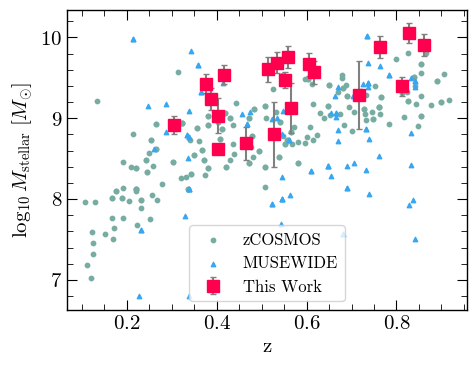

In [ ]:
# mass metallicity plot #

massz = ascii.read('plotdata/mass_z_cosmos.csv')
musepeas = musewide[musewide['WFoiii5007_ew']>1000]

fig, ax = pf.create_plot()

ax.scatter(massz['z'], massz['logmass'], color='#77aca2', s=10, label='zCOSMOS')
ax.scatter(musepeas['Z'], musepeas['STELLAR_MASS'], s=10, marker='^', c="#38a7f1", label='MUSEWIDE')
ax.errorbar(peas_final_new['z'], peas_final_new['logmstellar'], 
            yerr=peas_final_new['logmstellar_err'], fmt='s', ecolor='gray', 
            capsize=2, c='#ff004f', ms=8, label='This Work')

for ii,key in enumerate(['m25','m50','m75']):
    a_opt,b_opt = fit_logarithmic_curve(comp['zbin'],comp[key])
    grid = np.linspace(0,1,100)
    contour = logfn(grid, a_opt,b_opt)
    # ax.plot(grid+0.1, contour, color='k', alpha=(ii/5+0.2))
    # ax.plot(comp['zbin'],comp[key], color='k')


ax.scatter

ax.set_xlabel('z')
ax.set_ylabel(r'$\log_{10} M_{\mathrm{stellar}}\;[M_{\odot}]$')
ax.legend(fontsize=12)

pf.fix_plot([ax])

fig.savefig(f'figs/surveycomp.png', dpi=600, bbox_inches='tight')


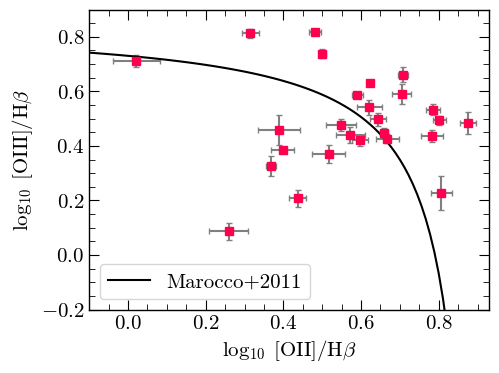

In [99]:
fig, ax = pf.create_plot()

logoiii = np.log10(selection['oiii5007_flux']/selection['hbeta_flux'])
logoiiierr = 0.432*selection['hbeta_flux_err']/selection['hbeta_flux']

logoii = np.log10((selection['oii3726_flux']+selection['oii3729_flux'])/selection['hbeta_flux'])
logoiierr = 0.432*selection['oii3729_flux_err']/selection['oii3729_flux']

mask = (logoiiierr/0.432 <0.3)&(logoiierr/0.432<0.3)

ax.errorbar(logoii[mask], logoiii[mask], xerr = logoiierr[mask], 
            yerr =logoiiierr[mask], fmt='s', color='#ff004f', ecolor='gray', capsize=2)

ax.set_xlabel(r'$\log_{10}\;\mathrm{[OII]/H}\beta$')
ax.set_ylabel(r'$\log_{10}\;\mathrm{[OIII]/H}\beta$')

grid = np.linspace(-.2,0.9,100)
seprel =  0.11/(grid - 0.92) + 0.85
ax.plot(grid, seprel, color='k', label='Marocco+2011')

ax.set_ylim(-.2,0.9)
ax.set_xlim(-0.1,0.93)

ax.legend()

pf.fix_plot([ax])

fig.savefig(f'figs/AGN.png', dpi=600, bbox_inches='tight')


/var/folders/6b/x84gj0ds47n3hjglw1wq1j8m0000gn/T/ipykernel_56159/2191002799.py:12: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "s" (-> marker='s'). The keyword argument will take precedence.
  ax.errorbar(logoii2, logoiii2, xerr = logoiierr2,
/var/folders/6b/x84gj0ds47n3hjglw1wq1j8m0000gn/T/ipykernel_56159/2191002799.py:28: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "x" (-> marker='x'). The keyword argument will take precedence.
  ax.errorbar(rhoadx, rhoady, xerr = rhoadx_err,


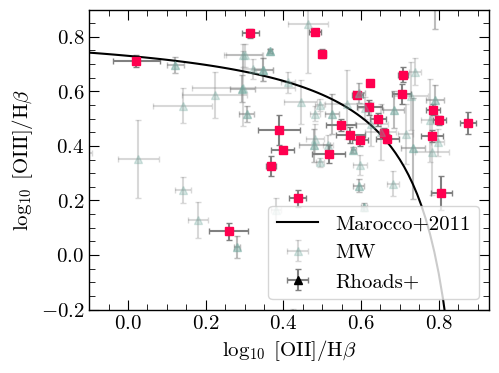

In [ ]:
fig, ax = pf.create_plot()

ax.errorbar(logoii[mask], logoiii[mask], xerr = logoiierr[mask], 
            yerr =logoiiierr[mask], fmt='s', color='#ff004f', ecolor='gray', capsize=2)

logoiii2 = np.log10(musepeas['WFoiii5007_flux']/musepeas['WFhbeta_flux'])
logoiiierr2 = 0.432*musepeas['WFhbeta_flux_err']/musepeas['WFhbeta_flux']

logoii2 = np.log10(musepeas['WFoii_flux']/musepeas['WFhbeta_flux'])
logoiierr2 = 0.432*musepeas['WFoii_flux_err']/musepeas['WFoii_flux']

ax.errorbar(logoii2, logoiii2, xerr = logoiierr2, 
            yerr =logoiiierr2, fmt='s', color='#77aca2', ecolor='gray', capsize=2, alpha=0.3,marker='^', label='MW')

ax.set_xlabel(r'$\log_{10}\;\mathrm{[OII]/H}\beta$')
ax.set_ylabel(r'$\log_{10}\;\mathrm{[OIII]/H}\beta$')

grid = np.linspace(-.2,0.9,100)
seprel =  0.11/(grid - 0.92) + 0.85
ax.plot(grid, seprel, color='k', label='Marocco+2011')

rhoadx = np.log10(rhoads['oii'])
rhoady = np.log10(rhoads['oiii'])

rhoadx_err = rhoads['pm2']/rhoads['oii']
rhoady_err = rhoads['pm']/rhoads['oiii']

# ax.errorbar(rhoadx, rhoady, xerr = rhoadx_err, 
#             yerr =rhoady_err, fmt='x', color='k', ecolor='gray', capsize=2,marker='^', label='Rhoads+')

ax.set_ylim(-.2,0.9)
ax.set_xlim(-0.1,0.93)

ax.legend()

pf.fix_plot([ax])

fig.savefig(f'figs/AGN_wcosmos.png', dpi=600, bbox_inches='tight')


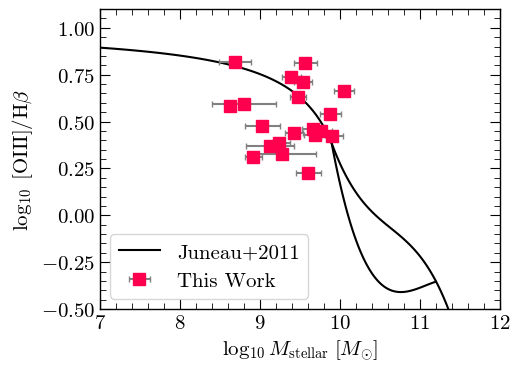

In [138]:
grid1 = np.linspace(6,9.9,100)
part1 = 0.37/(grid1 - 10.5) + 1

grid2 = np.linspace(9.9,11.2,100)
part2 = 800.492 - 217.328*grid2 + 19.6431*grid2**2 - 0.591349*grid2**3

grid3 = np.linspace(9.9,12,100)
part3 = 594.753 - 167.074*grid3 + 15.6748*grid3**2 - 0.491215*grid3**3

fig, ax  = pf.create_plot()

ax.plot(grid1,part1, color='k')
ax.plot(grid2,part2, color='k')
ax.plot(grid3,part3, color='k', label = 'Juneau+2011')

ax.set_ylabel(r'$\log_{10}\;\mathrm{[OIII]/H}\beta$')
ax.set_xlabel(r'$\log_{10} M_{\mathrm{stellar}}\;[M_{\odot}]$')

logoiii3 = np.log10(peas_final_new['oiii5007_flux']/peas_final_new['hbeta_flux'])
logoiiierr3 = 0.432*peas_final_new['hbeta_flux_err']/peas_final_new['hbeta_flux']

logoii3 = np.log10((peas_final_new['oii3726_flux']+peas_final_new['oii3729_flux'])/peas_final_new['hbeta_flux'])
logoiierr3 = 0.432*peas_final_new['oii3729_flux_err']/peas_final_new['oii3729_flux']

ax.errorbar( peas_final_new['logmstellar'], logoiii3,
            xerr=peas_final_new['logmstellar_err'], fmt='s', ecolor='gray', 
            capsize=2, c='#ff004f', ms=8, label='This Work')


# ax.scatter(musepeas['STELLAR_MASS'], musepeas['WFoiii5007_flux']/musepeas['WFhbeta_flux'])

ax.set_xlim(7,12)

ax.set_ylim(-0.5,1.1)

ax.legend()

pf.fix_plot([ax])
fig.savefig(f'figs/AGN_juneau.png', dpi=600, bbox_inches='tight')


In [142]:
def calculate_sfr_from_intrinsic_hbeta_array(intrinsic_hbeta_fluxes, redshifts, verbose=True):
    """
    Calculates the Star Formation Rate (SFR) from arrays of dust-corrected H-beta fluxes.

    This function is vectorized to efficiently handle arrays of galaxy data. It assumes
    the provided H-beta fluxes have already been corrected for dust extinction.

    Args:
        intrinsic_hbeta_fluxes (np.ndarray): 1D array of dust-corrected H-beta fluxes
                                             in erg/s/cm^2.
        redshifts (np.ndarray): 1D array of redshifts (z) for each galaxy.
        verbose (bool): If True, prints summary information about the calculation.

    Returns:
        np.ndarray: A numpy array containing the calculated Star Formation Rates
                    in solar masses per year (M_sun/yr).
                    Returns None if input arrays are invalid.
    """
    # --- Input Validation ---
    # Ensure inputs are numpy arrays for vectorized operations
    fluxes = np.asarray(intrinsic_hbeta_fluxes)
    z_values = np.asarray(redshifts)

    if fluxes.shape != z_values.shape:
        print("Error: Input flux and redshift arrays must have the same shape.")
        return None
    
    if np.any(fluxes <= 0) or np.any(z_values <= 0):
        print("Error: All flux and redshift values must be positive.")
        return None

    # --- Step 1: Calculate Luminosity Distance ---
    # astropy's cosmology functions are vectorized by default.
    luminosity_distances = cosmo.luminosity_distance(z_values)
    luminosity_distances_cm = luminosity_distances.to(u.cm).value

    # --- Step 2: Calculate Intrinsic H-beta Luminosity ---
    # All operations are element-wise on the numpy arrays.
    l_hbeta_intrinsic_array = fluxes * 4 * np.pi * luminosity_distances_cm**2

    # --- Step 3: Convert Intrinsic Luminosity to SFR ---
    # The calibration constant is the same as before.
    intrinsic_ratio = 2.86
    sfr_calibration_halpha = 5.5e-42
    sfr_calibration_hbeta = sfr_calibration_halpha * intrinsic_ratio
    
    sfr_array = sfr_calibration_hbeta * l_hbeta_intrinsic_array

    if verbose:
        print("--- SFR Array Calculation Summary ---")
        print(f"Processed {len(sfr_array)} galaxies.")
        print(f"Input Redshifts range: {np.min(z_values):.3f} - {np.max(z_values):.3f}")
        print(f"Calculated Luminosities range: {np.min(l_hbeta_intrinsic_array):.2e} - {np.max(l_hbeta_intrinsic_array):.2e} erg/s")
        print(f"Calculated SFRs range: {np.min(sfr_array):.3f} - {np.max(sfr_array):.3f} M_sun/yr")
        print("-------------------------------------")

    return sfr_array

In [157]:
mask = selection['hbeta_flux'] > 0
sfr = calculate_sfr_from_intrinsic_hbeta_array(selection['hbeta_flux'][mask]*1e-19, selection['z'][mask])

--- SFR Array Calculation Summary ---
Processed 32 galaxies.
Input Redshifts range: 0.152 - 0.861
Calculated Luminosities range: 5.75e+40 - 2.82e+42 erg/s
Calculated SFRs range: 0.905 - 44.364 M_sun/yr
-------------------------------------


True

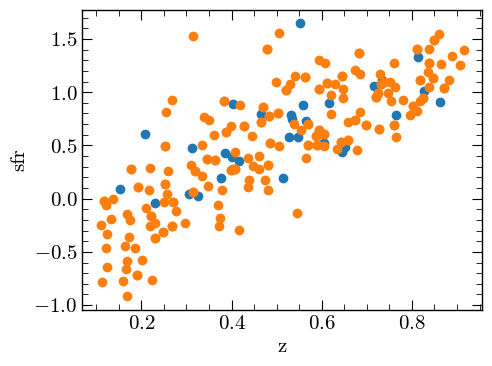

In [160]:
fig, ax = pf.create_plot()

cosmossfr = ascii.read('plotdata/sfr_z_cosmos.csv')

ax.scatter(selection['z'][mask],np.log10(sfr))
ax.scatter(cosmossfr['z'],cosmossfr['sfr'])

ax.set_ylabel('sfr')
ax.set_xlabel('z')

pf.fix_plot([ax])